In [1]:
import json
import numpy as np
import gymnasium as gym
import mani_skill.envs
from PIL import Image

from expert_policy import ScriptedExpert   # 실습 4 도 같은 것을 부른다 (expert_policy.py)


ENV_ID = "PickCube-v1"
MAX_EPISODE_STEPS = 200                        # week0 harness_check.md 확정값. expert 는 이 예산에서 검증됨 (최대 49 step 소비)
STEP_CAP = 250                                 # 내 루프의 상한. 환경 상한(200)보다 크게 두어 truncation 의 출처를 구분
DUMP_SEED = 100
EXPERT_CONTROL_MODE = "pd_ee_delta_pose"       # 실습 1-1 확정값 (scripted expert, outputs/expert_facts.md)

# max_episode_steps: 등록 기본값 50 대신 expert 가 검증된 예산 200 을 명시한다
# sensor_configs: week0 baseline 과 같은 224 로 수집 -- 기본값 128 이면 학습/eval 이미지 도메인이 어긋난다
env = gym.make(ENV_ID, obs_mode="rgb", control_mode=EXPERT_CONTROL_MODE,
               max_episode_steps=MAX_EPISODE_STEPS, sim_backend="physx_cpu",
               sensor_configs=dict(width=224, height=224))
obs, info = env.reset(seed=DUMP_SEED)
expert = ScriptedExpert(env)                   # 단계 상태를 들고 있으므로 env.reset 과 짝을 맞춘다
print("control mode:", env.unwrapped.control_mode)

frames = []
actions = []
tcp_poses = []
success = False


for step in range(STEP_CAP):
    # 카메라 렌더링은 sim_backend와 무관하게 GPU에서 수행되므로 CUDA 텐서를 CPU로 내린 뒤 numpy로 변환
    frame = obs["sensor_data"]["base_camera"]["rgb"].cpu().numpy()
    if frame.ndim == 4:
        frame = frame[0]
    frames.append(frame.astype(np.uint8))

    tcp_poses.append(np.asarray(env.unwrapped.agent.tcp.pose.raw_pose).reshape(-1))

    action = expert.act()                      # expert 가 이 상태에서 낼 action
    actions.append(np.asarray(action).reshape(-1))

    obs, reward, terminated, truncated, info = env.step(action)
    if info.get("success", False):
        success = True
        break
    if terminated or truncated:
        break

env.close()
print(f"수집 스텝: {len(actions)}, success: {success}")

# 자리표시 감지: expert 를 제대로 불렀다면 이 seed 는 성공한다 (week0 상한 대조 20/20).
# 여기서 멈춰야 실습 2 가 실패 궤적을 라벨로 만드는 사고를 막는다.
assert success, "expert 가 실패했다 -- action 호출부이거나 env 조건이 week0 과 다르다"

np.savez("outputs/expert_traj.npz",
         frames=np.stack(frames),
         actions=np.stack(actions),
         tcp_poses=np.stack(tcp_poses))
Image.fromarray(frames[0]).save("outputs/expert_traj_first.png")

with open("outputs/expert_traj_meta.json", "w") as f:
    json.dump({"env_id": ENV_ID, "seed": DUMP_SEED, "steps": len(actions), "control_mode": EXPERT_CONTROL_MODE, "max_episode_steps": MAX_EPISODE_STEPS, "success": bool(success)}, f, indent=2)
print("저장 완료: outputs/expert_traj.npz")

/workspace/study/physical-ai-study/Studies/Phase 4.5/.venv-sim/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/workspace/study/physical-ai-study/Studies/Phase 4.5/.venv-sim/lib/python3.12/site-packages/sapien/_vulkan_tricks.py:78: UserWarning: Failed to find Vulkan ICD file. This is probably due to an incorrect or partial installation of the NVIDIA driver. SAPIEN will attempt to provide an ICD file anyway but it may not work.
  warn(


control mode: pd_ee_delta_pose
수집 스텝: 36, success: True
저장 완료: outputs/expert_traj.npz


In [ ]:
import numpy as np

from action_transform import to_openvla_actions   # 실습 3/4 도 같은 함수를 부른다

data = np.load("outputs/expert_traj.npz")
expert_actions = data["actions"]                   # 라벨의 원재료 -- expert 가 명령한 값
tcp_poses = data["tcp_poses"]                      # 라벨에는 안 쓴다. 실습 3 의 비교 기준

print("expert_actions shape:", expert_actions.shape)
print("tcp_poses shape:", tcp_poses.shape)
print("첫 pose:", tcp_poses[0])                    # 위치 3 + 쿼터니언 4(wxyz) 확인

# 라벨은 expert 가 "명령한" 델타를 물리 단위로 되돌린 값이다. 실제로 움직인 거리가 아니다
# -- PD 는 한 스텝에 명령의 약 42% 만 따라가므로, 실제 이동량을 라벨로 쓰면 그 값이 다시
# 명령이 되어 궤적이 재현되지 않는다 (outputs/roundtrip_check.md).
# 단위는 원시 물리량(m, rad) 그대로 둔다 -- 정규화는 week2 학습 파이프라인이 한다
openvla_actions = to_openvla_actions(expert_actions)

print("openvla_actions shape:", openvla_actions.shape)   # (T-1, 7) 이어야 한다
print("차원 별 범위")
for dim in range(openvla_actions.shape[1]):
    column = openvla_actions[:, dim]
    print(f"dim{dim}: min={column.min():+.4f} max={column.max():+.4f}")

# gripper 는 열림/닫힘 두 상태 신호다. 중간값이 잔뜩이면 성분을 잘못 뽑은 것이다
print("gripper 고유값:", sorted(set(openvla_actions[:, 6].tolist())))

np.save("outputs/openvla_actions.npy", openvla_actions)
print("저장 완료: outputs/openvla_actions.npy")

In [3]:
import numpy as np
import gymnasium as gym
import mani_skill.envs

from action_transform import to_maniskill_action   # 실습 2 와 같은 파일의 반대 방향 함수

ENV_ID = "PickCube-v1"
MAX_EPISODE_STEPS = 200                         # 실습 1 과 같은 예산 -- 기본값 50 이면 재생이 잘린다
DUMP_SEED = 100                                 # 실습 1 과 같은 seed -> 같은 초기 배치
STRONG_TOL = 1e-3                               # 강한 기준: 위치 오차 허용치 (m). 근거는 roundtrip_check.md 에

openvla_actions = np.load("outputs/openvla_actions.npy")
original = np.load("outputs/expert_traj.npz")["tcp_poses"]

# sim_backend 는 실습 1 덤프와 동일하게 -- 물리 백엔드가 다르면 수치가 달라져 비교가 흐려진다
env = gym.make(ENV_ID, obs_mode="rgb", control_mode="pd_ee_delta_pose", max_episode_steps=MAX_EPISODE_STEPS, sim_backend="physx_cpu")
obs, info = env.reset(seed=DUMP_SEED)
replay_poses = []
success = False

for action_7d in openvla_actions:
    replay_poses.append(np.asarray(env.unwrapped.agent.tcp.pose.raw_pose).reshape(-1))
    action = to_maniskill_action(action_7d)     # 원시 물리량 -> ManiSkill 정규화값 (정변환)
    obs, reward, terminated, truncated, info = env.step(action)
    if info.get("success", False):
        success = True
        break
    if terminated or truncated:
        break

env.close()
replay_poses = np.stack(replay_poses)

compare_len = min(len(replay_poses), len(original))
position_error = np.linalg.norm(
    replay_poses[:compare_len, 0:3] - original[:compare_len, 0:3], axis=1
)
print(f"\n비교 스탭 수: {compare_len} (재생 {len(replay_poses)} / 원본 {len(original)})")
print(f"위치 오차 mean={position_error.mean():.6f} max={position_error.max():.6f} m")
print(f"강한 기준(max < {STRONG_TOL}): {'통과' if position_error.max() < STRONG_TOL else '실패'}")

# 위치 오차만 보면 회전 라벨이 틀려도 잡히지 않는다. 진단용으로 회전 오차도 함께 본다.
# 이 expert 는 회전 델타를 전 단계에서 0 으로 두므로 값 자체는 작게 나온다
rotation_error = np.linalg.norm(
    replay_poses[:compare_len, 3:7] - original[:compare_len, 3:7], axis=1
)
print(f"쿼터니언 오차 mean={rotation_error.mean():.6f} max={rotation_error.max():.6f}")

print(f"약한 기준(success): {'통과' if success else '실패'}")


비교 스탭 수: 35 (재생 35 / 원본 36)
위치 오차 mean=0.082281 max=0.106913 m
강한 기준(max < 0.001): 실패
쿼터니언 오차 mean=0.000986 max=0.002817
약한 기준(success): 실패


In [1]:
import glob
import json
import numpy as np
import gymnasium as gym
import mani_skill.envs

from expert_policy import ScriptedExpert   # 실습 1 과 같은 정책을 부른다

ENV_ID = "PickCube-v1"
MAX_EPISODE_STEPS = 200
STEP_CAP = 250
EXPERT_CONTROL_MODE = "pd_ee_delta_pose"
N_EPISODES = 100
SMOKE_EPISODES = 3                              # 앞 N episode 로 expert 호출부를 먼저 검사한다
SUCCESS_FLOOR = 0.8                             # 이 아래면 수집물을 신뢰하지 않는다 (week0 상한 20/20)

# 이전 수집물이 남아 있으면 실습 6 의 glob 이 옛 episode 까지 함께 센다
stale = glob.glob("outputs/dataset/ep*.npz")
assert not stale, f"이전 수집물 {len(stale)}개가 남아 있다 -- rm outputs/dataset/ep*.npz 후 다시 실행"

with open("../week0/outputs/zeroshot_baseline.json") as f:
    eval_seeds = set(json.load(f)["seeds"])
print(f"eval seed {len(eval_seeds)}개 예약됨: {sorted(eval_seeds)}")

train_seeds = [seed for seed in range(1000, 1000 + N_EPISODES * 2)
               if seed not in eval_seeds][:N_EPISODES]
assert not (set(train_seeds) & eval_seeds), "학습 seed 에 eval seed 가 섞였다"
print(f"학습 seed {len(train_seeds)}개, 겹침 0 확인")

env = gym.make(ENV_ID, obs_mode="rgb", control_mode=EXPERT_CONTROL_MODE,
           max_episode_steps=MAX_EPISODE_STEPS, sim_backend="physx_cpu",
           sensor_configs=dict(width=224, height=224))
expert = ScriptedExpert(env)
episode_index = 0                               # 저장 파일 번호
success_count = 0                               # expert 성공률 통계용

for episode_ordinal, seed in enumerate(train_seeds):
    obs, info = env.reset(seed=seed)
    expert.reset()                              # 단계 상태를 되돌린다 -- 빼면 앞 episode 의 phase 를 물고 간다
    frames, actions, tcp_poses = [], [], []
    success = False
    for step in range(STEP_CAP):
        frame = obs["sensor_data"]["base_camera"]["rgb"].cpu().numpy()
        if frame.ndim == 4:
            frame = frame[0]
        frames.append(frame.astype(np.uint8))
        tcp_poses.append(np.asarray(env.unwrapped.agent.tcp.pose.raw_pose).reshape(-1))
        action = expert.act()
        actions.append(np.asarray(action).reshape(-1))
        obs, reward, terminated, truncated, info = env.step(action)
        if info.get("success", False):
            success = True
            break
        if terminated or truncated:
            break

    success_count += int(success)
    # 실패 episode 는 학습에 넣지 않되 통계에는 남긴다
    if success:
        np.savez(f"outputs/dataset/ep{episode_index:04d}.npz",
                 frames=np.stack(frames),
                 actions=np.stack(actions),
                 tcp_poses=np.stack(tcp_poses),
                 seed=seed)                     # seed 를 데이터에 박아 둔다 (재현·검증용)
        episode_index += 1
    print(f"   seed{seed}: success={success} steps={len(actions)}")

    # 조기 차단: 100 episode 를 다 돌린 뒤에 알아차리면 수집 시간을 통째로 버린다
    if episode_ordinal + 1 == SMOKE_EPISODES:
        assert success_count == SMOKE_EPISODES, \
            f"앞 {SMOKE_EPISODES} episode 중 {success_count}개만 성공 -- expert 호출부를 확인한다"

env.close()

# 성공률이 바닥을 밑돌면 데이터가 아니라 잡음을 모은 것이다.
# 메타를 먼저 쓰면 잘못된 수집이 정상 산출물처럼 남으므로 저장 전에 판정한다.
success_rate = success_count / len(train_seeds)
assert success_rate >= SUCCESS_FLOOR, \
    f"expert 성공률 {success_rate:.2f} < {SUCCESS_FLOOR} -- 데이터로 쓸 수 없다"

with open("outputs/dataset/collect_meta.json", "w") as f:
    json.dump({"env_id": ENV_ID, "control_mode": EXPERT_CONTROL_MODE,
               "max_episode_steps": MAX_EPISODE_STEPS,
               "step_cap": STEP_CAP, "train_seeds": train_seeds,
               "eval_seeds_excluded": sorted(eval_seeds),
               "episodes_saved": episode_index,
               "expert_success_rate": success_rate,
               "instruction": "pick up the cube"}, f, indent=2)
print(f"\n저장 episode: {episode_index} / expert 성공률: {success_count}/{len(train_seeds)}")

/workspace/study/physical-ai-study/Studies/Phase 4/.venv-vla/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/workspace/study/physical-ai-study/Studies/Phase 4/.venv-vla/lib/python3.12/site-packages/sapien/_vulkan_tricks.py:78: UserWarning: Failed to find Vulkan ICD file. This is probably due to an incorrect or partial installation of the NVIDIA driver. SAPIEN will attempt to provide an ICD file anyway but it may not work.
  warn(


AssertionError: 이전 수집물 100개가 남아 있다 -- rm outputs/dataset/ep*.npz 후 다시 실행

In [ ]:
import glob
import numpy as np

from action_transform import to_openvla_actions   # 실습 2 와 같은 함수 -- 복사하면 라벨이 어긋난다

# 수집된 각 episode 에 OpenVLA 표현 라벨을 붙인다.
# 실습 4 는 원재료(frames / actions / tcp_poses)만 저장한다. 라벨은 실습 3 의 round-trip 이
# 통과한 뒤에 만들어야 하므로 단계를 분리해 둔 것이다.
files = sorted(glob.glob("outputs/dataset/ep*.npz"))
assert files, "수집된 episode 가 없다 -- 실습 4 를 먼저 실행한다"
print(f"episode 파일 {len(files)}개에 라벨을 붙인다")

for path in files:
    # npz 는 지연 로딩이라 파일을 닫기 전에 전부 읽어 둬야 한다.
    # 같은 경로에 다시 쓰는 중에 읽으면 아카이브가 깨진다
    with np.load(path) as data:
        arrays = {key: data[key] for key in data.files}
    # 매번 다시 계산한다 -- 이미 있으면 건너뛰면, 실습 2 를 고쳐도 옛 라벨이 남는다
    arrays["openvla_actions"] = to_openvla_actions(arrays["actions"])
    np.savez(path, **arrays)                    # npz 는 키 추가가 안 되므로 파일을 통째로 다시 쓴다

# 붙인 결과를 전수 확인한다
labels = [np.load(path)["openvla_actions"] for path in files]
lengths = [(len(np.load(path)["frames"]), len(label)) for path, label in zip(files, labels)]
assert all(frame_count == label_count + 1 for frame_count, label_count in lengths), \
    "frames(T) 와 라벨(T-1) 의 길이 관계가 깨졌다"
stacked = np.concatenate(labels)
print(f"라벨 총 {len(stacked)}개 (frames 총합보다 episode 수만큼 적어야 정상)")
print("차원 별 범위")
for dim in range(stacked.shape[1]):
    column = stacked[:, dim]
    print(f"dim{dim}: min={column.min():+.4f} max={column.max():+.4f}")
print("gripper 고유값:", sorted(set(stacked[:, 6].tolist())))

In [1]:
import torch
from transformers import AutoModelForVision2Seq, BitsAndBytesConfig

bnb_config = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type="nf4",
                                bnb_4bit_use_double_quant=True,
                                bnb_4bit_compute_dtype=torch.float16)
vla = AutoModelForVision2Seq.from_pretrained("openvla/openvla-7b",
                                             attn_implementation="eager",
                                             torch_dtype=torch.float16,
                                             low_cpu_mem_usage=True,
                                             trust_remote_code=True,
                                             quantization_config=bnb_config)

names = sorted(vla.norm_stats.keys())
print(f"데이터셋 {len(names)}개")
for name in names:
    print("  ", name)

print("sim 관련 후보: ", [n for n in names if "sim" in n.lower()])
print("franka 관련 후보: ", [n for n in names if "franka" in n.lower()])

/workspace/study/physical-ai-study/Studies/Phase 4/.venv-vla/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/workspace/study/physical-ai-study/Studies/Phase 4/.venv-vla/lib/python3.12/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]/workspace/study/physical-ai-study/Studies/Phase 4/.venv-vla/lib/python3.12/site-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
Loadin

데이터셋 25개
   austin_buds_dataset_converted_externally_to_rlds
   austin_sailor_dataset_converted_externally_to_rlds
   austin_sirius_dataset_converted_externally_to_rlds
   bc_z
   berkeley_autolab_ur5
   berkeley_cable_routing
   berkeley_fanuc_manipulation
   bridge_orig
   cmu_stretch
   dlr_edan_shared_control_converted_externally_to_rlds
   dobbe
   fmb_dataset
   fractal20220817_data
   furniture_bench_dataset_converted_externally_to_rlds
   iamlab_cmu_pickup_insert_converted_externally_to_rlds
   jaco_play
   kuka
   nyu_franka_play_dataset_converted_externally_to_rlds
   roboturk
   stanford_hydra_dataset_converted_externally_to_rlds
   taco_play
   toto
   ucsd_kitchen_dataset_converted_externally_to_rlds
   utaustin_mutex
   viola
sim 관련 후보:  []
franka 관련 후보:  ['nyu_franka_play_dataset_converted_externally_to_rlds']


episode 파일 100개
총 스텝(학습 샘플) 수: 3760
episode 당 평균 스텝: 37.6
expert 성공률: 1.00
저장 완료: outputs/action_hist.png
episode 길이: 최소 9 / 최대 50
20 step 미만 episode (seed, 길이): [(1086, 9)]


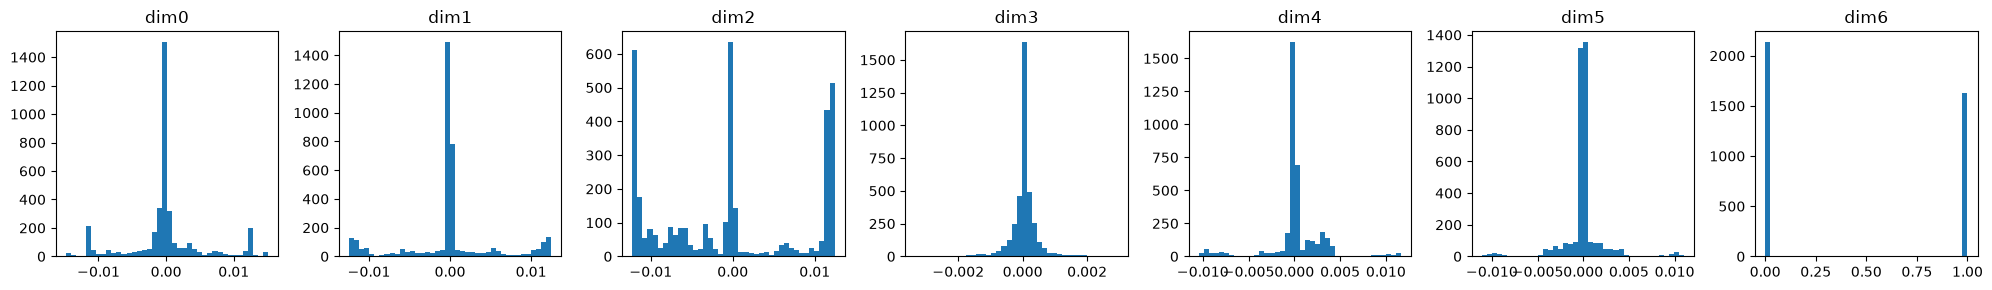

In [1]:
import glob
import json
import numpy as np
import matplotlib.pyplot as plt

files = sorted(glob.glob("outputs/dataset/ep*.npz"))
print(f"episode 파일 {len(files)}개")

with open("outputs/dataset/collect_meta.json") as f:
    meta = json.load(f)

# 두 번째 겹침 검사. 실습 4 는 "생성한 목록" 을 봤고 이것은 "실제로 저장된 파일" 을 본다
seeds_in_files = [int(np.load(path)["seed"]) for path in files]
assert not (set(seeds_in_files) & set(meta["eval_seeds_excluded"])), "eval seed 오염"

# 학습 샘플 수는 라벨 개수로 센다. frames 는 T 장이지만 라벨은 T-1 개이므로
# actions 로 세면 episode 수만큼 부풀려진다
total_steps = sum(len(np.load(path)["openvla_actions"]) for path in files)
print(f"총 스텝(학습 샘플) 수: {total_steps}")
print(f"episode 당 평균 스텝: {total_steps / max(len(files), 1):.1f}")
print(f"expert 성공률: {meta['expert_success_rate']:.2f}")

all_actions = np.concatenate([np.load(path)["openvla_actions"] for path in files])
fig, axes = plt.subplots(1, 7, figsize=(20, 3))
for dim in range(7):
    axes[dim].hist(all_actions[:, dim], bins=40)   # 차원별 히스토그램으로 이상값을 눈으로 잡는다
    axes[dim].set_title(f"dim{dim}")
plt.tight_layout()
plt.savefig("outputs/action_hist.png")
print("저장 완료: outputs/action_hist.png")

# episode 길이의 이상값 점검. 유난히 짧은 episode 는 "목표가 큐브 초기 위치 근처에 떨어져
# 공짜로 성공한" seed 일 수 있다 (week0 harness_check.md 하한 대조)
steps_per_episode = [len(np.load(path)["openvla_actions"]) for path in files]
print(f"episode 길이: 최소 {min(steps_per_episode)} / 최대 {max(steps_per_episode)}")
short = [(int(np.load(path)["seed"]), step_count)
         for path, step_count in zip(files, steps_per_episode) if step_count < 20]
print("20 step 미만 episode (seed, 길이):", short)